# Analyze Inferences

Inferences for parameter estimation (namely, the elastic constant $K$ and the activity constant $\alpha$) are generated in `parameter_estimation/src/infer_parameters.py` and saved as a CSV file.  This notebook unpacks these values and plots them in a more readable way.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

Just for convenience, we would like to define a function that will take our file and give us back the relevant parameters as a list (numpy array).

In [58]:
def get_parameters(filename):
    df = pd.read_csv(filename)      # Read the csv into a pandas object
    return df['k'], df['z']         # Return the two columns as numpy arrays

`infer_parameters.py` saves the two parameters at every timepoint in the experiment.  We want to plot the mean values for each experiment.

In [89]:
def calculate_averages(files):
    k_avgs = []
    z_avgs = []

    for file in files:                              # We want an average for each parameter for data file
        k_list, z_list = get_parameters(file)
        k_avgs.append(np.average(k_list))
        z_avgs.append(np.average(z_list))

    return k_avgs, z_avgs

def plot_averages(files):
    k_avgs, z_avgs = calculate_averages(files)

    fig, ax = plt.subplots()
    ax.scatter(k_avgs, z_avgs)
    fig.suptitle('Parameter Inferences', fontsize=18)
    ax.set_xlabel(r'Elastic Constant $K$', fontsize=16)
    ax.set_ylabel(r'Activity Constant $\alpha$', fontsize=16)


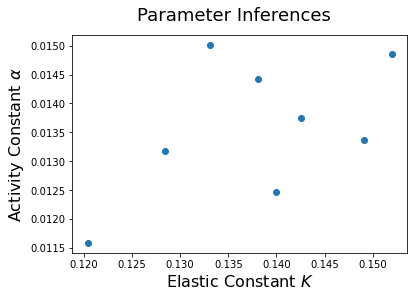

In [90]:
dir = '../../../data/inferences/ConvNextParameterEstimator_KZ_v3'
files = [
    file for file in Path(dir).iterdir()
    if file.is_file()
    and file.suffix == ".csv"
    and not file.name.startswith("._")          # Had to include this bit because my code keeps picking up the metadata files too
]

plot_averages(files)